# Анализ пар подлежащее-сказуемое
Извлечение и анализ синтаксических пар из текстов новостей

## 1. Импорт библиотек

In [9]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from natasha import (
    Segmenter,
    MorphVocab,
    NewsEmbedding,
    NewsMorphTagger,
    NewsSyntaxParser,
    Doc
)

plt.rcParams['font.family'] = 'DejaVu Sans'

## 2. Инициализация моделей Natasha
Загружаем предобученные модели для морфологического и синтаксического анализа

In [2]:
segmenter = Segmenter()
morph_vocab = MorphVocab()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)
syntax_parser = NewsSyntaxParser(emb)

C:\Users\danii\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 3. Функция загрузки данных

In [3]:
def load_texts(file_path):
    df = pd.read_excel(file_path, engine='openpyxl')
    df = df[df['text'].notna()]
    return df['text'].tolist()

## 4. Функция парсинга предложений
Извлекает пары подлежащее-сказуемое из текста

In [4]:
def parse_sentence(text):
    pairs = []

    if len(text) > 3000:
        text = text[:3000]

    try:
        doc = Doc(text)
        doc.segment(segmenter)
        doc.tag_morph(morph_tagger)
        doc.parse_syntax(syntax_parser)

        for sent in doc.sents:
            tokens_dict = {token.id: token for token in sent.tokens}

            predicates = []
            for token in sent.tokens:
                if token.pos == 'VERB' and token.rel == 'root':
                    predicates.append(token)

            for predicate in predicates:
                subject = None

                for token in sent.tokens:
                    if hasattr(token, 'head_id'):
                        head_id = token.head_id
                    else:
                        continue

                    if head_id == predicate.id and token.rel in ['nsubj', 'nsubj:pass']:
                        subject = token
                        break

                if not subject:
                    for token in sent.tokens:
                        if token.pos in ['NOUN', 'PROPN', 'PRON'] and token.id < predicate.id:
                            subject = token

                if subject and predicate:
                    pairs.append((subject.text.lower(), predicate.text.lower()))

    except Exception:
        pass

    return pairs

## 5. Функция построения зависимостей
Обрабатывает все тексты и подсчитывает частоту пар

In [5]:
def build_cooccurrence_dependencies(texts):
    all_pairs = []

    for i, text in enumerate(texts):
        pairs = parse_sentence(text)
        all_pairs.extend(pairs)

        if (i + 1) % 50 == 0:
            print(f"Обработано текстов: {i + 1}/{len(texts)}, найдено пар: {len(all_pairs)}")

    return Counter(all_pairs)

## 6. Функция визуализации

In [6]:
def visualize_results(counter, top_n=20):
    top_pairs = counter.most_common(min(top_n, len(counter)))

    labels = [f"{s} → {p}" for (s, p), _ in top_pairs]
    counts = [count for _, count in top_pairs]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(labels)), counts, color='steelblue')
    plt.yticks(range(len(labels)), labels)
    plt.xlabel('Частота')
    plt.title(f'Топ-{len(labels)} пар (Подлежащее → Сказуемое)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('results.png', dpi=150)
    plt.show()

## 7. Загрузка и обработка данных

In [7]:
file_path = "LentaRU.xlsx"
texts = load_texts(file_path)

print("Извлечение пар подлежащее-сказуемое...\n")
cooccurrences = build_cooccurrence_dependencies(texts)

Извлечение пар подлежащее-сказуемое...

Обработано текстов: 50/5999, найдено пар: 463
Обработано текстов: 100/5999, найдено пар: 925
Обработано текстов: 150/5999, найдено пар: 1353
Обработано текстов: 200/5999, найдено пар: 1751
Обработано текстов: 250/5999, найдено пар: 2159
Обработано текстов: 300/5999, найдено пар: 2545
Обработано текстов: 350/5999, найдено пар: 2916
Обработано текстов: 400/5999, найдено пар: 3262
Обработано текстов: 450/5999, найдено пар: 3632
Обработано текстов: 500/5999, найдено пар: 3996
Обработано текстов: 550/5999, найдено пар: 4348
Обработано текстов: 600/5999, найдено пар: 4725
Обработано текстов: 650/5999, найдено пар: 5088
Обработано текстов: 700/5999, найдено пар: 5485
Обработано текстов: 750/5999, найдено пар: 5833
Обработано текстов: 800/5999, найдено пар: 6189
Обработано текстов: 850/5999, найдено пар: 6591
Обработано текстов: 900/5999, найдено пар: 6969
Обработано текстов: 950/5999, найдено пар: 7345
Обработано текстов: 1000/5999, найдено пар: 7767
Об

## 8. Результаты и визуализация


Найдено уникальных пар: 28765
Всего вхождений: 48142

Топ-20 наиболее частых сочетаний:
1. риа - сообщает: 997
2. агентство - сообщает: 298
3. интерфакс - сообщает: 285
4. риа - передает: 275
5. ак - сообщает: 255
6. bloomberg - сообщает: 237
7. решение - принято: 236
8. газета - сообщает: 233
9. прайм-тасс - сообщает: 215
10. reuters - сообщает: 195
11. он - отметил: 177
12. рбк - сообщает: 174
13. индекс - вырос: 149
14. министр - заявил: 139
15. речь - идет: 122
16. вице-премьер - заявил: 114
17. интерфакс - передает: 114
18. индекс - упал: 114
19. заместитель - заявил: 112
20. он - заявил: 109


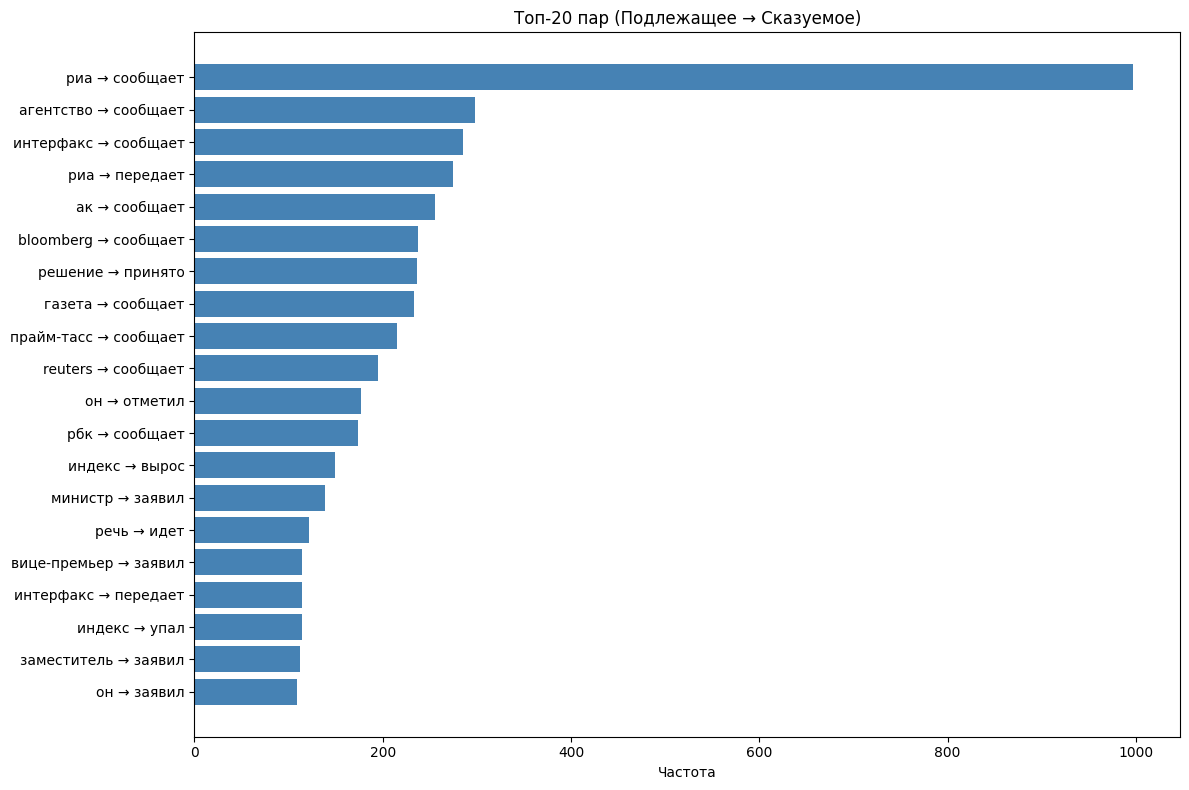

In [8]:
print(f"\nНайдено уникальных пар: {len(cooccurrences)}")
print(f"Всего вхождений: {sum(cooccurrences.values())}\n")

print("Топ-20 наиболее частых сочетаний:")
for i, ((subject, predicate), count) in enumerate(cooccurrences.most_common(20), 1):
    print(f"{i}. {subject} - {predicate}: {count}")

visualize_results(cooccurrences, top_n=20)